# Timestep constraints

In [ ]:
from lucifex.fdm import AB, CN, AM
from lucifex.sim import run, xdmf_to_npz
from lucifex.viz import plot_line, save_figure, get_ipynb_file_name, set_ipynb_variable
from crocodil.dns.system_a import dns_system_a, SYSTEM_A_REFERENCE
from lucifex.solver import OptionsPETSc

STORE = 1
WRITE = None
DIR_ROOT = f'.figures/{get_ipynb_file_name()}'
DIR_PARAMS = ('Ra', 'Da', 'epsilon', 'sr', 'cr', 'Nx', 'Ny')

NX = 100
NY = 100
COURANT_ADV = 0.75
COURANT_DIFF = 0.75
COURANT_REAC = 0.1

simulation = dns_system_a(
    store_delta=STORE, 
    write_delta=WRITE, 
    dir_root=DIR_ROOT, 
    dir_params=DIR_PARAMS,
)(
    Nx=NX,
    Ny=NY,
    scaling='advective',
    **SYSTEM_A_REFERENCE,
    D_adv=AB(1)@CN, 
    D_diff=AB(1)@CN,
    D_reac=AB(1)@AM(1),
    D_src=AB(1),
    D_evol=AM(1)@AB(1),
    dt_max=0.1,
    courant_adv=COURANT_ADV,
    courant_diff=COURANT_DIFF,
    courant_reac=COURANT_REAC,
    flow_petsc=(OptionsPETSc('cg', 'hypre'), None),
    diagnostic=True,
)

n_stop = set_ipynb_variable('N_STOP', 600)
t_stop = 20.0
dt_init = 1e-6
n_init = 10
run(simulation, n_stop=n_stop, t_stop=t_stop, dt_init=dt_init, n_init=n_init)
if WRITE: xdmf_to_npz(simulation, delete_xdmf=False)

s, c, u, psi = simulation['s', 'c', 'u', 'psi']

Environment variable `N_STOP=500`


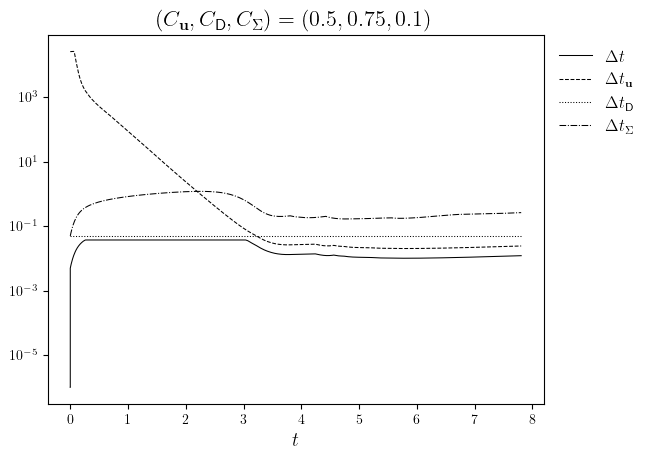

In [ ]:
dt, dtU, dtD, dtSigma = simulation['dt', 'dtU', 'dtD', 'dtSigma']

title = f'$(C_{{\mathbf{{u}}}}, C_{{\mathsf{{D}}}}, C_\Sigma)=({COURANT_ADV}, {COURANT_DIFF}, {COURANT_REAC})$'
fig, ax = plot_line(
    [
        (dt.time_series, dt.value_series), 
        (dtU.time_series, dtU.value_series), 
        (dtD.time_series, dtD.value_series), 
        (dtSigma.time_series, dtSigma.value_series),
    ],
    x_label='$t$',
    title=title,
    legend_labels=[
        '$\Delta t$', 
        '$\Delta t_{\mathbf{u}}$', 
        '$\Delta t_{\mathsf{D}}$', 
        '$\Delta t_{\Sigma}$',
    ],
)
ax.set_yscale('log')
save_figure('dt(t)', simulation.dir_path, prefix_ipynb=False)(fig)

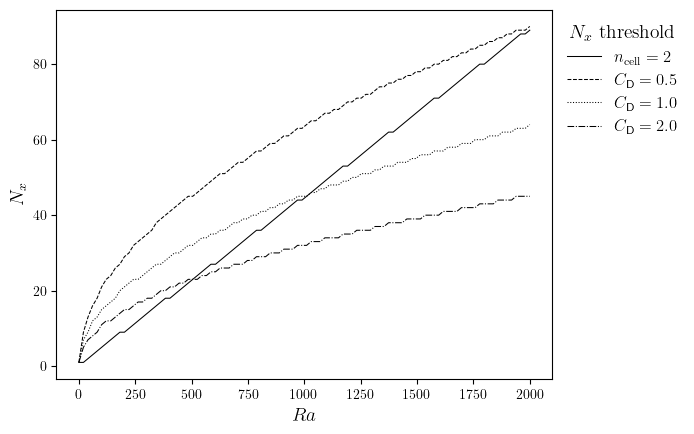

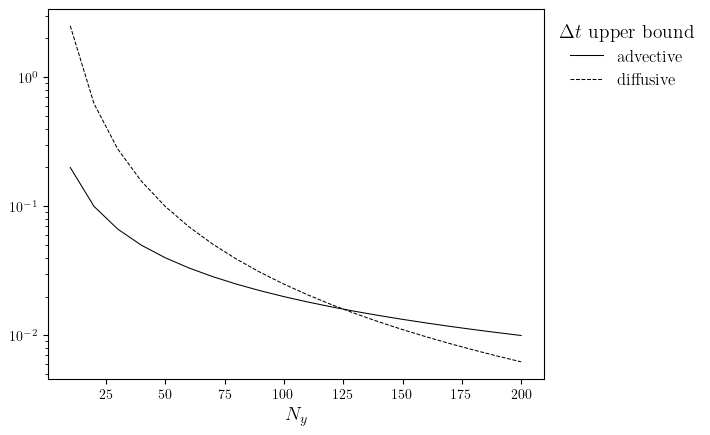

In [2]:
import numpy as np
from lucifex.fdm import diffusive_timestep, advective_timestep
from lucifex.viz import plot_line
from crocodil.dns.theory import threshold_Nx, diffusive_Nx

Lx = 2.0
Ly = 1.0
n_per_cell = 2
courant = 1.0
courant_2 = 2 * courant

Ra_max = 2e3
Ra_axis = np.linspace(1e-2, Ra_max, num=100)
thresh_line = [threshold_Nx(Ra, Lx, Ly, n_per_cell) for Ra in Ra_axis]
cD_opts = (0.5, 1.0, 2.0)
courant_lines = [
    [diffusive_Nx(Ra, Lx, cD) for Ra in Ra_axis] for cD in cD_opts
]

fig, ax = plot_line(
    [(Ra_axis, ln) for ln in (thresh_line, *courant_lines)],
    x_label='$Ra$',
    y_label='$N_x$',
    cyc='black',
    legend_labels=[
        f'$n_{{\mathrm{{cell}}}}={n_per_cell}$', 
        *[
            f'$C_{{\mathsf{{D}}}}={cD}$'
            for cD in cD_opts
        ],
    ],
    legend_title='$N_x$ threshold',
)

uMax_estm = 0.5
Ra = 500.0
Ly = 1.0
Ny_axis = range(10, 210, 10)
dtU_line = [advective_timestep(uMax_estm, Ly / Ny) for Ny in Ny_axis]
dtD_line = [diffusive_timestep(1/Ra, Ly / Ny) for Ny in Ny_axis]

fig, ax = plot_line(
    [(Ny_axis, ln) for ln in (dtU_line, dtD_line)],
    x_label='$N_y$',
    cyc='black',
    legend_labels=[
        'advective', 
        'diffusive', 
    ],
    legend_title='$\Delta t$ upper bound',
)
ax.set_yscale('log')